In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from PIL import Image

print("TF version:", tf.__version__)

TF version: 2.19.0


In [7]:
# Run this in a Colab cell
!wget -q "http://www.cedar.buffalo.edu/NIJ/data/signatures.rar"
!apt-get install -y unrar
!unrar x signatures.rar

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.

UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from signatures.rar

Creating    signatures                                                OK
Creating    signatures/full_forg                                      OK
Extracting  signatures/full_forg/forgeries_10_1.png                        0%  OK 
Extracting  signatures/full_forg/forgeries_10_10.png                       0%  OK 
Extracting  signatures/full_forg/forgeries_10_11.png                       0%  OK 
Extracting  signatures/full_forg/forgeries_10_12.png                       0%  OK 
Extracting  signatures/full_forg/forgeries_10_13.png                       0%  OK 
Extracting  signatures/full_forg/forgeries_10_14.png               

Genuine signatures: 1321
Forged signatures: 1321


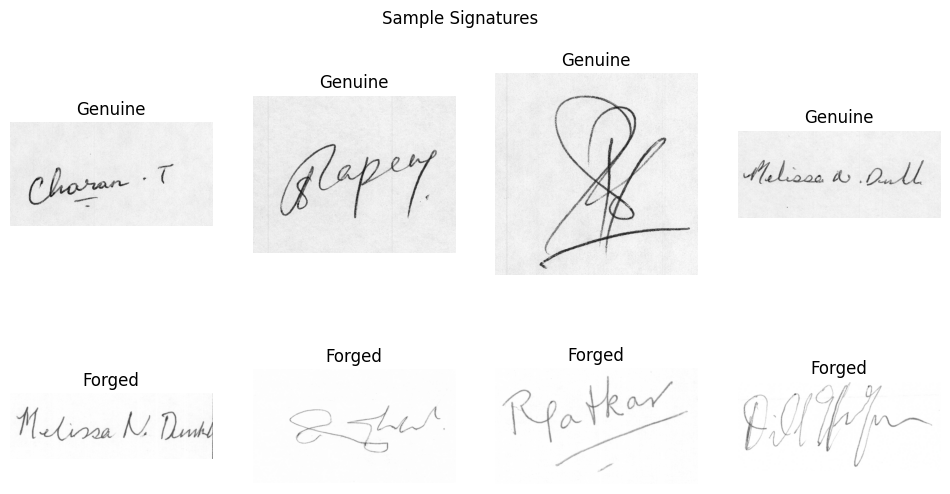

In [10]:
# Check what's in the dataset
import os

genuine_path = '/content/signatures/full_org'   # adjust path after download
forged_path  = '/content/signatures/full_forg'

print("Genuine signatures:", len(os.listdir(genuine_path)))
print("Forged signatures:", len(os.listdir(forged_path)))

# Visualize samples
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

genuine_files = os.listdir(genuine_path)[:4]
forged_files  = os.listdir(forged_path)[:4]

for i, fname in enumerate(genuine_files):
    img = Image.open(os.path.join(genuine_path, fname))
    axes[0][i].imshow(img, cmap='gray')
    axes[0][i].set_title('Genuine')
    axes[0][i].axis('off')

for i, fname in enumerate(forged_files):
    img = Image.open(os.path.join(forged_path, fname))
    axes[1][i].imshow(img, cmap='gray')
    axes[1][i].set_title('Forged')
    axes[1][i].axis('off')

plt.suptitle("Sample Signatures")
plt.savefig('samples.png')
plt.show()

In [13]:
IMG_SIZE = (105, 105)  # standard size for Siamese networks

def preprocess_image(path):
    img = Image.open(path).convert('L')  # grayscale
    img = img.resize(IMG_SIZE)
    img = np.array(img) / 255.0          # normalize 0-1
    img = img.reshape(105, 105, 1)       # add channel dimension
    return img

# Test it
sample = preprocess_image(os.path.join(genuine_path, genuine_files[0]))
print("Image shape:", sample.shape)  # should be (105, 105, 1)

Image shape: (105, 105, 1)


In [16]:
def create_pairs(genuine_path, forged_path):
    pairs  = []
    labels = []

    def get_image_files(path):
        return sorted([
            f for f in os.listdir(path)
            if os.path.isfile(os.path.join(path, f)) and
               f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])

    genuine_files = get_image_files(genuine_path)
    forged_files  = get_image_files(forged_path)

    # Positive pairs
    for i in range(len(genuine_files)):
        for j in range(i+1, min(i+4, len(genuine_files))):
            img1 = preprocess_image(os.path.join(genuine_path, genuine_files[i]))
            img2 = preprocess_image(os.path.join(genuine_path, genuine_files[j]))
            pairs.append([img1, img2])
            labels.append(1)

    # Negative pairs
    for i in range(min(len(genuine_files), len(forged_files))):
        img1 = preprocess_image(os.path.join(genuine_path, genuine_files[i]))
        img2 = preprocess_image(os.path.join(forged_path,  forged_files[i]))
        pairs.append([img1, img2])
        labels.append(0)

    return np.array(pairs), np.array(labels)

pairs, labels = create_pairs(genuine_path, forged_path)
print("Total pairs:", len(pairs))
print("Positive pairs:", sum(labels))
print("Negative pairs:", len(labels) - sum(labels))

Total pairs: 5274
Positive pairs: 3954
Negative pairs: 1320


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    pairs, labels,
    test_size=0.2,
    random_state=42
)

# Separate the pairs into two input arrays
train_img1 = X_train[:, 0]  # shape: (N, 105, 105, 1)
train_img2 = X_train[:, 1]
test_img1  = X_test[:, 0]
test_img2  = X_test[:, 1]

print("Training pairs:", len(train_img1))
print("Test pairs:", len(test_img1))

Training pairs: 4219
Test pairs: 1055


In [18]:
def build_base_cnn(input_shape):
    """This CNN is shared by both inputs"""
    inp = tf.keras.Input(shape=input_shape)

    x = tf.keras.layers.Conv2D(64, (10,10), activation='relu')(inp)
    x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.Conv2D(128, (7,7), activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.Conv2D(128, (4,4), activation='relu')(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    x = tf.keras.layers.Conv2D(256, (4,4), activation='relu')(x)

    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(4096, activation='sigmoid')(x)

    return tf.keras.Model(inp, x)


def build_siamese_network(input_shape):
    # Two inputs
    input_a = tf.keras.Input(shape=input_shape)
    input_b = tf.keras.Input(shape=input_shape)

    # Shared CNN (same weights for both)
    base_cnn = build_base_cnn(input_shape)

    # Pass both images through the same CNN
    feat_a = base_cnn(input_a)
    feat_b = base_cnn(input_b)

    # Compute L1 distance between features
    distance = tf.keras.layers.Lambda(
        lambda tensors: tf.abs(tensors[0] - tensors[1])
    )([feat_a, feat_b])

    # Final prediction
    output = tf.keras.layers.Dense(1, activation='sigmoid')(distance)

    model = tf.keras.Model(inputs=[input_a, input_b], outputs=output)
    return model


model = build_siamese_network((105, 105, 1))
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 105, 105,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 105, 105,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ (None, 4096)      │ 38,947,648 │ input_layer[0][0… │
│ (Functional)        │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 4096)      │          0 │ functional[0][0], │
│                     │                   │            │ functional[1][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │      4,097 │ lambda[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 38,951,745 (148.59 MB)

 Trainable params: 38,951,745 (148.59 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    [train_img1, train_img2], y_train,
    validation_split=0.1,
    batch_size=16,
    epochs=20,
    verbose=1
)

Epoch 1/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 26s 65ms/step - accuracy: 0.7925 - loss: 0.5552 - val_accuracy: 0.8886 - val_loss: 0.3908
Epoch 2/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.8235 - loss: 0.5006 - val_accuracy: 0.8649 - val_loss: 0.4231
Epoch 3/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step - accuracy: 0.8623 - loss: 0.3718 - val_accuracy: 0.8981 - val_loss: 0.2910
Epoch 4/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.8962 - loss: 0.2680 - val_accuracy: 0.8863 - val_loss: 0.2438
Epoch 5/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.9083 - loss: 0.2351 - val_accuracy: 0.9408 - val_loss: 0.1603
Epoch 6/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.9255 - loss: 0.1984 - val_accuracy: 0.9502 - val_loss: 0.1802
Epoch 7/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.9436 - loss: 0.1556 - val_accuracy: 0.9455 - val_loss: 0.1428
Epoch 8/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - accuracy: 0.9476 - loss: 0.1358 - 

In [20]:
test_loss, test_acc = model.evaluate(
    [test_img1, test_img2], y_test, verbose=0
)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 96.21%
Test Loss: 0.1371


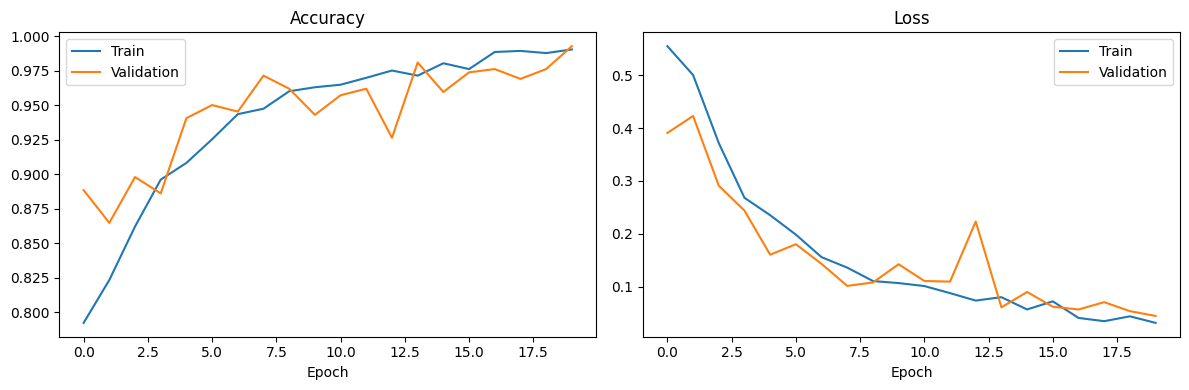

In [21]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.savefig('training_curves.png')
plt.show()

33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step


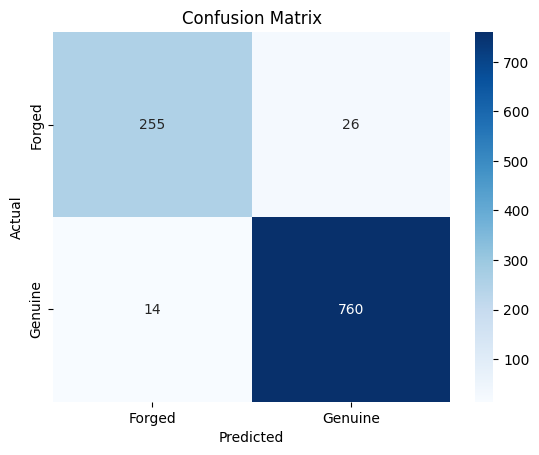

              precision    recall  f1-score   support

      Forged       0.95      0.91      0.93       281
     Genuine       0.97      0.98      0.97       774

    accuracy                           0.96      1055
   macro avg       0.96      0.94      0.95      1055
weighted avg       0.96      0.96      0.96      1055



In [22]:
y_pred = (model.predict([test_img1, test_img2]) > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Forged','Genuine'],
            yticklabels=['Forged','Genuine'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('confusion_matrix.png')
plt.show()

print(classification_report(y_test, y_pred,
      target_names=['Forged', 'Genuine']))

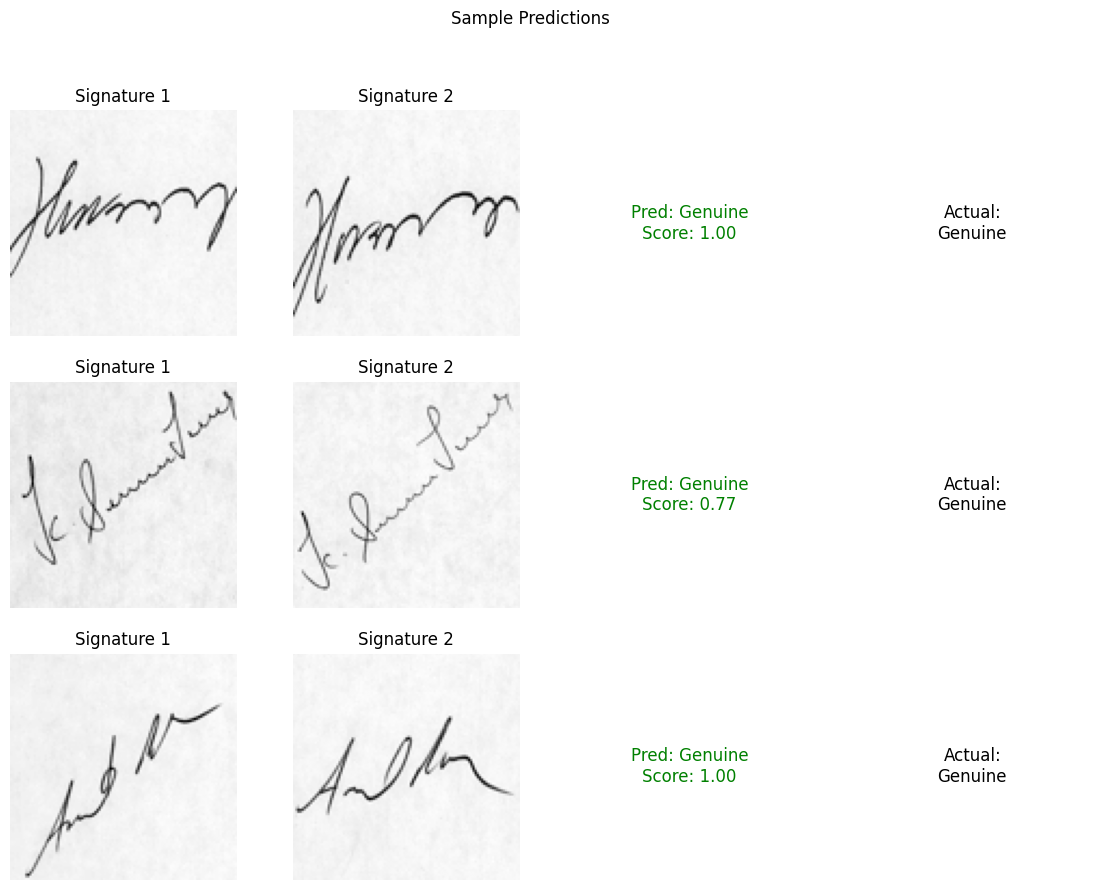

In [23]:
fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for i in range(3):
    idx = random.randint(0, len(test_img1)-1)

    pred  = model.predict(
        [test_img1[idx:idx+1], test_img2[idx:idx+1]], verbose=0
    )[0][0]
    actual = y_test[idx]
    result = "Genuine" if pred > 0.5 else "Forged"
    color  = 'green' if (pred > 0.5) == actual else 'red'

    axes[i][0].imshow(test_img1[idx].reshape(105,105), cmap='gray')
    axes[i][0].set_title('Signature 1')
    axes[i][0].axis('off')

    axes[i][1].imshow(test_img2[idx].reshape(105,105), cmap='gray')
    axes[i][1].set_title('Signature 2')
    axes[i][1].axis('off')

    axes[i][2].text(0.5, 0.5, f"Pred: {result}\nScore: {pred:.2f}",
                    ha='center', va='center', fontsize=12, color=color)
    axes[i][2].axis('off')

    axes[i][3].text(0.5, 0.5, f"Actual:\n{'Genuine' if actual else 'Forged'}",
                    ha='center', va='center', fontsize=12)
    axes[i][3].axis('off')

plt.suptitle("Sample Predictions")
plt.savefig('predictions.png')
plt.show()

In [24]:
model.save('signature_verification_model.h5')
print("Model saved!")

Model saved!
